# Enstrophy convergence

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from ml.config import SpinupConfig, ConvergenceConfig
from ml.data.isca_segment import read_segments
from ml.data.isca_segment import validate_segment_dataset
from ml.diagnostics.enstrophy import mean_enstrophy
from ml.diagnostics.spinup import find_spinup_time

from ml.diagnostics.convergence import compute_time_mean_zonal_mean, zonal_mean_convergence_errors, find_zonal_mean_convergence_time

plt.rcParams["figure.dpi"] = 120

sim_dir = Path("../../output/barotropic_stirring-T85/simulations/fc0e25-0")

spinup_config = SpinupConfig(
    z_threshold=2.0,
    stable_time=5,
    window_size=10,
)

convergence_config = ConvergenceConfig(
    threshold=0.05,
    hold=3,
)

In [2]:

ds = read_segments(str(sim_dir / "run*" / "atmos_daily.nc"), decode_time=True)
vor = ds.vor.values
u = ds.ucomp.values
lat = ds.lat.values
num_samples, spatial_shape = validate_segment_dataset(ds, x_vars=[], y_vars=[])
print(f"num_samples={num_samples}, spatial_shape={spatial_shape}")

num_samples=1050, spatial_shape=(128, 256)


Text(0, 0.5, 'Mean Enstrophy')

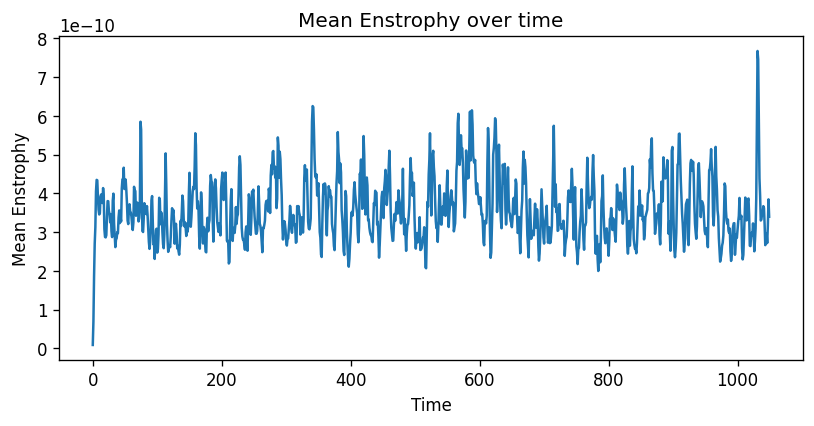

In [3]:
enstrophy = mean_enstrophy(vor, lat)
fig, ax = plt.subplots(figsize=(8, 3.5))
plt.plot(enstrophy)
ax.set_title("Mean Enstrophy over time")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Enstrophy")

spinup_time = 10


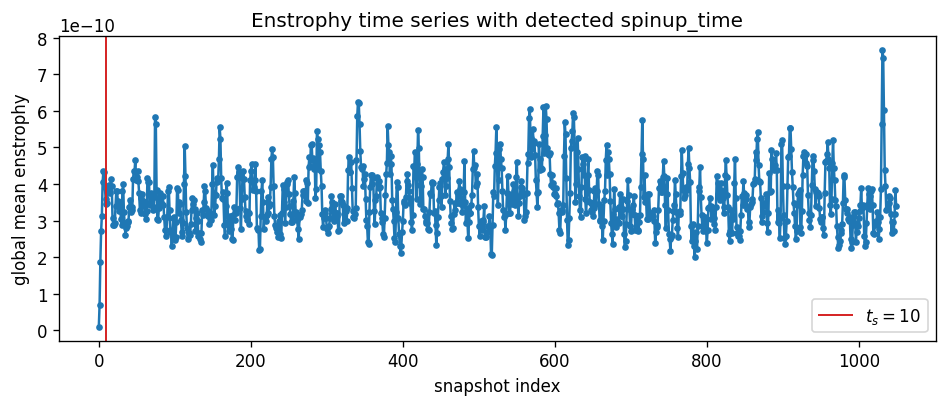

In [4]:
spinup_time = find_spinup_time(diagnostic=enstrophy, **spinup_config.to_kwargs())
print(f"spinup_time = {spinup_time}")

if spinup_time:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(enstrophy, marker="o", markersize=3)
    ax.axvline(spinup_time, color="C3", linestyle="-", linewidth=1.2, label=rf"$t_s = {spinup_time}$")
    ax.set_xlabel("snapshot index")
    ax.set_ylabel("global mean enstrophy")
    ax.set_title("Enstrophy time series with detected spinup_time")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [5]:
t_c = find_zonal_mean_convergence_time(u, lat, spinup_time, **convergence_config.to_kwargs())
if t_c is None:
    raise ValueError("Failed to reach convergence")

diagnostic_reference = compute_time_mean_zonal_mean(u, t_c, num_samples)
errors = zonal_mean_convergence_errors(u, lat, spinup_time)
i_values = np.arange(1, len(errors) + 1)
convergence_time = t_c - spinup_time
print(f"t_c = {t_c}, convergence_time = {convergence_time} (time took to converge after spinup)")

t_c = 252, convergence_time = 242 (time took to converge after spinup)


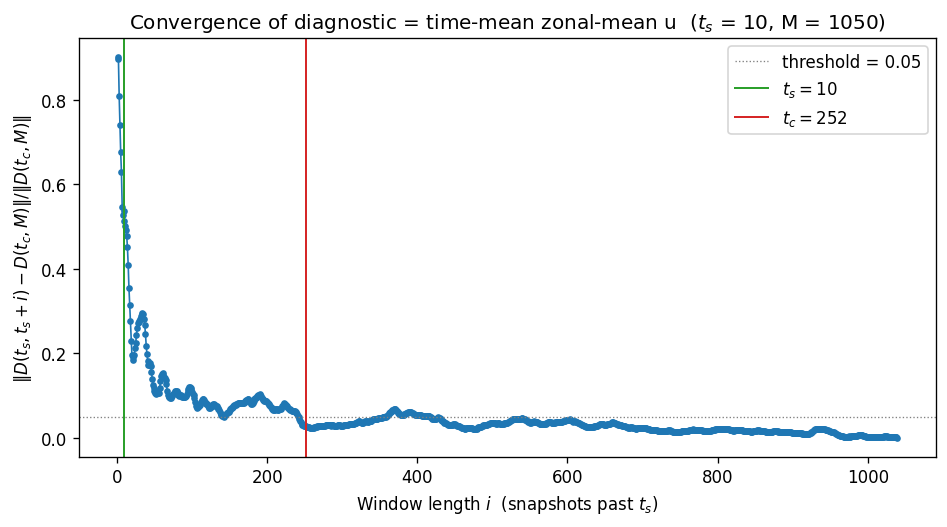

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(i_values, errors, marker="o", markersize=3, linewidth=1)
ax.axhline(convergence_config.threshold, color="gray", linestyle=":", linewidth=0.8, label=f"threshold = {convergence_config.threshold}")
ax.axvline(spinup_time, color="C2", linestyle="-", linewidth=1.2, label=rf"$t_s = {spinup_time}$")
if t_c is not None:
    ax.axvline(t_c, color="C3", linestyle="-", linewidth=1.2, label=rf"$t_c = {t_c}$")
ax.set_xlabel(r"Window length $i$  (snapshots past $t_s$)")
ax.set_ylabel(r"$\| D(t_s, t_s+i) - D(t_c, M) \| / \| D(t_c, M) \|$")
ax.set_title(f"Convergence of diagnostic = time-mean zonal-mean u  ($t_s$ = {spinup_time}, M = {num_samples})")
ax.legend()
plt.tight_layout()
plt.show()

## Evolution of the diagnostic profile

Grid of $N$ frames at evenly-spaced window lengths $i$. Each panel shows the partial-window diagnostic $D(t_s, t_s+i)$ (blue) against the reference $D(t_s, M)$ (red). Convergence appears as the blue line settling onto the red.

In [7]:
N_FRAMES = 12
i_frames = np.linspace(1, num_samples - spinup_time - 1, N_FRAMES).astype(int)
diagnostics_frames = np.stack([
    compute_time_mean_zonal_mean(u, spinup_time, spinup_time + i)
    for i in i_frames
])
print(f"i frames: {i_frames.tolist()}")

i frames: [1, 95, 189, 284, 378, 472, 567, 661, 755, 850, 944, 1039]


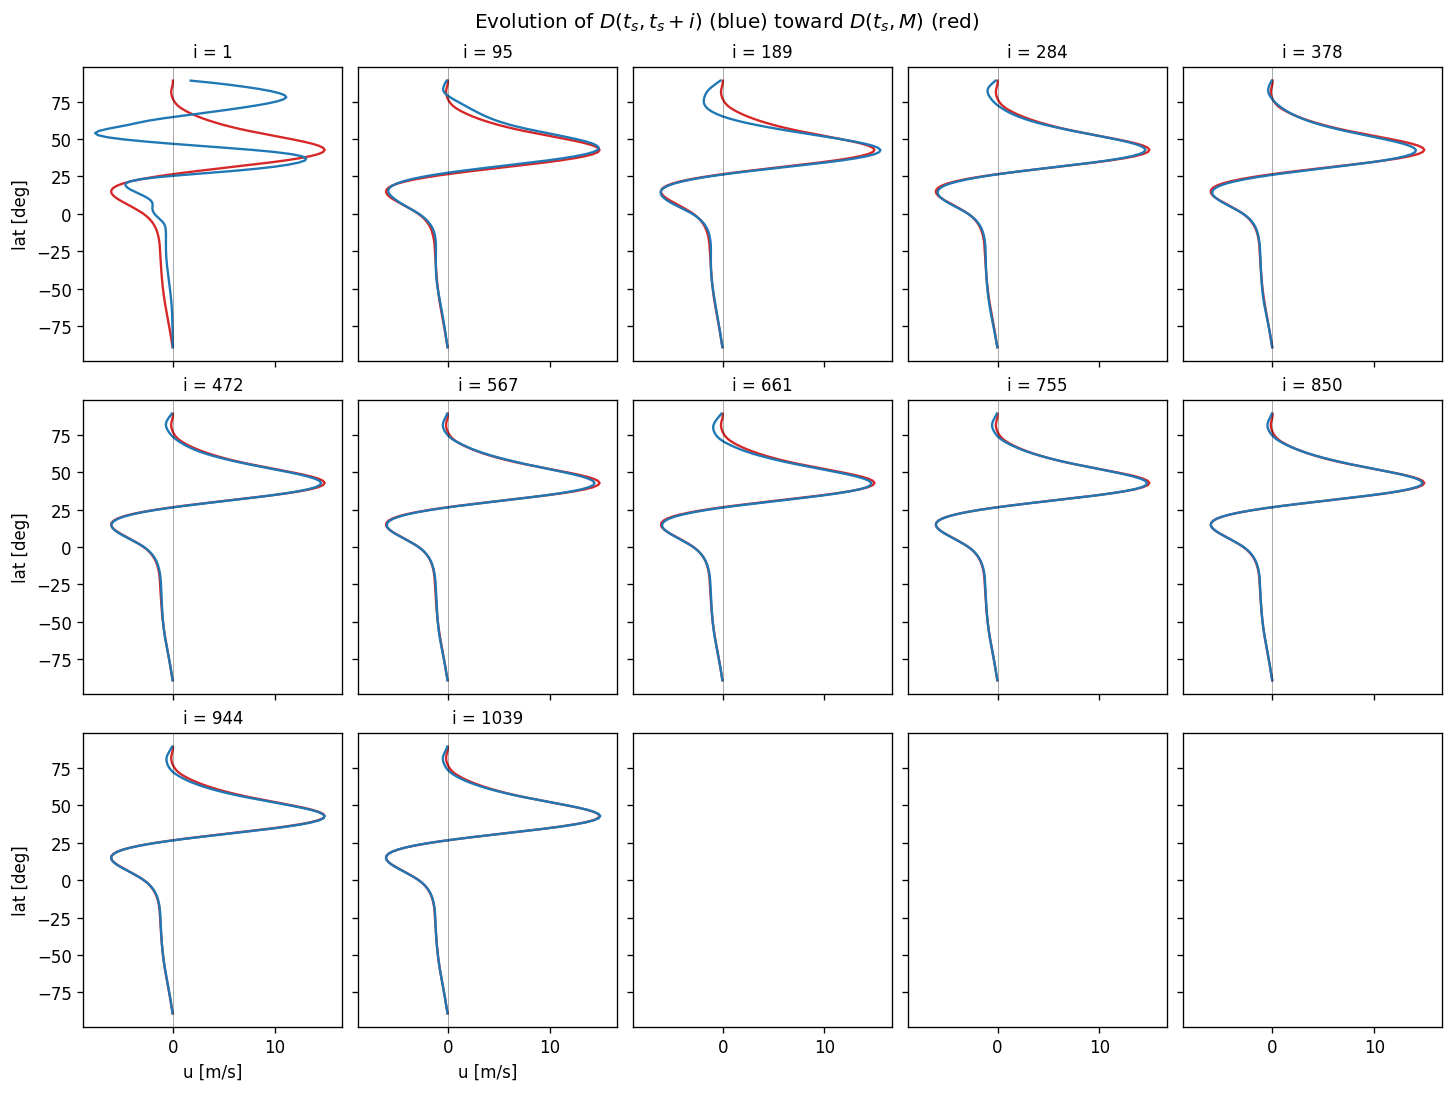

In [ ]:
ncols = 5
nrows = (N_FRAMES + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols, figsize=(ncols * 2.4, nrows * 3.0),
    sharex=True, sharey=True, constrained_layout=True,
)

for k, i in enumerate(i_frames):
    ax = axes.flat[k]
    ax.plot(diagnostic_reference, lat, color="C3", linewidth=1.4)
    ax.plot(diagnostics_frames[k], lat, color="C0", linewidth=1.4)
    ax.axvline(0.0, color="k", linewidth=0.4, alpha=0.5)
    ax.set_title(f"i = {i}", fontsize=10)
    if k % ncols == 0:
        ax.set_ylabel("lat [deg]")
    if k >= (nrows - 1) * ncols:
        ax.set_xlabel("u [m/s]")

fig.suptitle(r"Evolution of $D(t_s, t_s+i)$ (blue) toward $D(t_c, M)$ (red)")
plt.show()